In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("startup_metrics.csv")
df.head()

,month,mrr,active_users,cac,churn_rate,marketing_spend,burn_rate
0,0,545000,545,1200,0.027554,69600,326327
1,1,603000,603,1200,0.024202,85200,306889
2,2,619000,619,1200,0.051274,55200,317788
3,3,688000,688,1200,0.029439,104400,341877
4,4,741000,741,1200,0.022688,81600,347855


In [8]:
df.describe() #The Detailed Description of Data

,month,mrr,active_users,cac,churn_rate,marketing_spend,burn_rate
count,72.00000,7.200000e+01,72.000000,72.0,72.000000,72.000000,72.000000
mean,35.50000,1.345139e+06,1345.138889,1200.0,0.039604,81350.000000,328589.402778
std,20.92845,2.932569e+05,293.256860,0.0,0.011178,16631.270394,32725.785486
min,0.00000,5.450000e+05,545.000000,1200.0,0.021179,48000.000000,259940.000000
25%,17.75000,1.181250e+06,1181.250000,1200.0,0.029037,72000.000000,306392.250000
50%,35.50000,1.466500e+06,1466.500000,1200.0,0.040523,82800.000000,326344.000000
75%,53.25000,1.590250e+06,1590.250000,1200.0,0.048126,93600.000000,351416.250000
max,71.00000,1.641000e+06,1641.000000,1200.0,0.059929,106800.000000,400705.000000


In [10]:
df.isna().sum() #No Null values present

month              0
mrr                0
active_users       0
cac                0
churn_rate         0
marketing_spend    0
burn_rate          0
dtype: int64

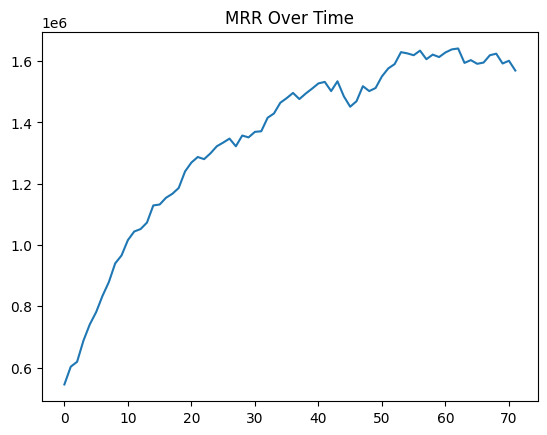

In [5]:
month = df["month"]
mrr = df["mrr"]

plt.plot(month, mrr)
plt.title("MRR Over Time")
plt.show()

In [33]:
df["mrr_growth_rate"] = df["mrr"].pct_change()

In [34]:
df["rolling_avg"] = df["mrr"].rolling(window=3).mean()

In [35]:
df["burn_ratio"] = df["burn_rate"] / df["mrr"]

In [36]:
df["net_growth"] = df["active_users"].diff()

In [38]:
df = df.dropna()
df

,month,mrr,active_users,cac,churn_rate,marketing_spend,burn_rate,rolling_avg,mrr_growth_rate,burn_ratio,net_growth
4,4,741000,741,1200,0.022688,81600,347855,6.826667e+05,0.077035,0.469440,53.0
5,5,781000,781,1200,0.041704,84000,310323,7.366667e+05,0.053981,0.397341,40.0
6,6,834000,834,1200,0.032130,93600,352086,7.853333e+05,0.067862,0.422165,53.0
7,7,879000,879,1200,0.051562,105600,361883,8.313333e+05,0.053957,0.411699,45.0
8,8,940000,940,1200,0.027782,102000,381966,8.843333e+05,0.069397,0.406347,61.0
...,...,...,...,...,...,...,...,...,...,...,...
67,67,1619000,1619,1200,0.023470,73200,294049,1.601667e+06,0.015047,0.181624,24.0
68,68,1624000,1624,1200,0.035881,75600,325360,1.612667e+06,0.003088,0.200345,5.0
69,69,1592000,1592,1200,0.059104,75600,301113,1.611667e+06,-0.019704,0.189141,-32.0
70,70,1601000,1601,1200,0.048340,102000,340150,1.605667e+06,0.005653,0.212461,9.0


In [45]:
rolling_avg = df["rolling_avg"]
growth_rate = df["mrr_growth_rate"]
burn_ratio = df["burn_ratio"]
net_growth = df["net_growth"]
churn_rate = df["churn_rate"]
month = df["month"]
active_users = df["active_users"]

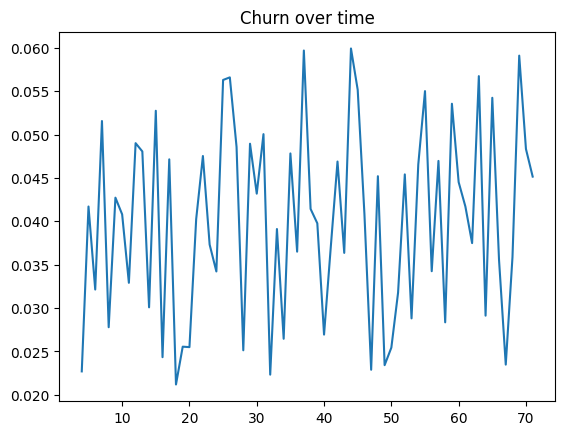

In [47]:
plt.plot(month, churn_rate)
plt.title("Churn over time")
plt.show()

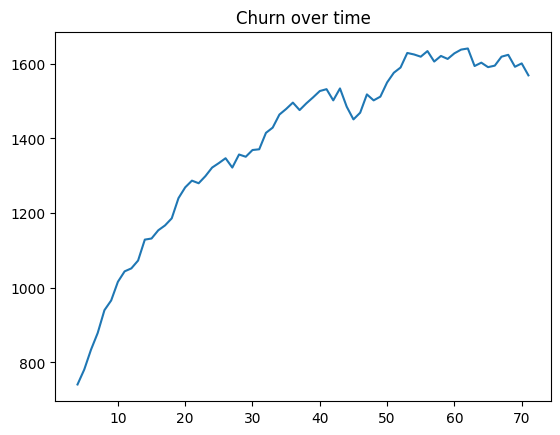

In [48]:
plt.plot(month,active_users)
plt.title("Churn over time")
plt.show()

In [49]:
df.to_csv("updated_startup_metric.csv", index=False)